In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import os
os.makedirs("results/logistic_regression", exist_ok=True)

In [26]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

In [27]:
def calculate_gradient(theta, X, y):
    m = y.size
    X = np.c_[np.ones(X.shape[0]), X]
    return (X.T @ (sigmoid(X @ theta) - y)) / m

In [28]:
def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b = np.c_[np.ones(X.shape[0]), X]
    theta = np.zeros(X_b.shape[1])

    for i in range(num_iter):
        grad = calculate_gradient(theta, X, y)
        theta -= alpha * grad

        if np.linalg.norm(grad) < tol:
            break

    return theta


def predict_prob(X, theta): # Will give us the probability between 0 and 1
    X_b = np.c_[np.ones(X.shape[0]), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta) >= threshold).astype(int)



In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [30]:
df = pd.read_csv("telco_churn_cleaned.csv")

In [31]:
print(df["Churn"].unique())

[0 1]


In [32]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [33]:
y = df["Churn"] #Target
X = df.drop(columns=["Churn"]) #Features
print(X.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No inter

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = X_train_scaled.astype(float)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = X_test_scaled.astype(float)

y_train = y_train.values
y_test = y_test.values

theta_hat = gradient_descent(X_train_scaled, y_train, alpha=0.1)
y_pred_train = predict(X_train_scaled, theta_hat)
y_pred_test = predict(X_test_scaled, theta_hat)
y_prob_test = predict_prob(X_test_scaled, theta_hat)


train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)


Logistic Regression Results
------------------------------
Accuracy:  0.7918
Precision: 0.6188
Recall:    0.5642
F1-Score:  0.5902
ROC-AUC:   0.8312

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



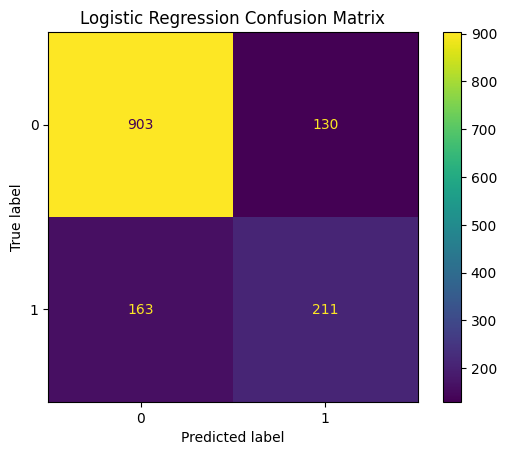

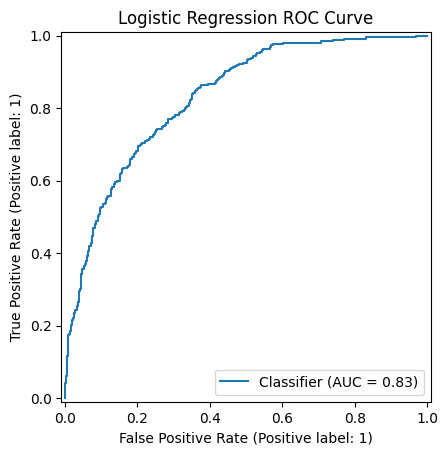


Files saved to results/logistic_regression/


In [38]:
# Calculate metrics
print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_test):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("results/logistic_regression/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_test)
plt.title("Logistic Regression ROC Curve")
plt.savefig("results/logistic_regression/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Create results dataframe
results_df = pd.DataFrame([{
    "Model": "Baseline Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1": f1_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(y_test, y_prob_test)
}])

# Create test predictions dataframe
test_predictions = pd.DataFrame(X_test_scaled, columns=X.columns)
test_predictions["y_true"] = y_test
test_predictions["lr_prob"] = y_prob_test
test_predictions["lr_pred"] = y_pred_test

# Save CSVs
results_df.to_csv("results/logistic_regression/lr_model_comparison.csv", index=False)
test_predictions.to_csv("results/logistic_regression/lr_test_predictions.csv", index=False)

print("\nFiles saved to results/logistic_regression/")